# Copa do Mundo 2026 — Rodada 1 da fase de grupos

Análise dos 24 jogos já disputados (primeira rodada da fase de grupos), com foco em gols, resultados e quem já está em situação de risco no grupo.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("dados/partidas.csv")
df.shape

(104, 23)

In [5]:
df.dtypes.to_frame("tipo")

,tipo
match_id,int64
utc_date,str
status,str
stage,str
group,str
matchday,float64
venue,float64
attendance,float64
home_team_id,float64
home_team,str


In [8]:
df.head(3)

,match_id,utc_date,status,stage,group,matchday,venue,attendance,home_team_id,home_team,away_team_id,away_team,home_coach,away_coach,home_formation,away_formation,winner,duration,fulltime_home,fulltime_away,halftime_home,halftime_away,referee
0,537327,2026-06-11T19:00:00Z,FINISHED,GROUP_STAGE,GROUP_A,1.0,NaN,NaN,769.0,Mexico,774.0,South Africa,NaN,NaN,NaN,NaN,HOME_TEAM,REGULAR,2.0,0.0,1.0,0.0,Wilton Sampaio
1,537328,2026-06-12T02:00:00Z,FINISHED,GROUP_STAGE,GROUP_A,1.0,NaN,NaN,772.0,South Korea,798.0,Czechia,NaN,NaN,NaN,NaN,HOME_TEAM,REGULAR,2.0,1.0,0.0,0.0,Amin Omar
2,537333,2026-06-12T19:00:00Z,FINISHED,GROUP_STAGE,GROUP_B,1.0,NaN,NaN,828.0,Canada,1060.0,Bosnia-Herzegovina,NaN,NaN,NaN,NaN,DRAW,REGULAR,1.0,1.0,0.0,1.0,Facundo Tello


In [7]:
df[["home_team", "away_team", "referee"]].head()

,home_team,away_team,referee
0,Mexico,South Africa,Wilton Sampaio
1,South Korea,Czechia,Amin Omar
2,Canada,Bosnia-Herzegovina,Facundo Tello
3,United States,Paraguay,Danny Makkelie
4,Qatar,Switzerland,Said Martinez


## Quantos gols saíram na primeira rodada?

In [7]:
rodada1 = df[(df["matchday"] == 1.0) & (df["status"] == "FINISHED")].copy()
rodada1.shape

(24, 23)

In [8]:
rodada1["total_gols"] = rodada1["fulltime_home"] + rodada1["fulltime_away"]
rodada1["total_gols"].describe().to_frame("total_gols")

,total_gols
count,24.000000
mean,3.125000
std,1.918163
min,0.000000
25%,2.000000
50%,2.500000
75%,4.000000
max,8.000000


Média de `3,1 gols` por jogo na rodada 1, com um jogo de até 8 gols. Bastante movimentado. Vale ver qual foi esse jogo.

In [9]:
rodada1.sort_values("total_gols", ascending=False)[["home_team", "fulltime_home", "away_team", "fulltime_away"]].head()

,home_team,fulltime_home,away_team,fulltime_away
8,Germany,7.0,Curaçao,1.0
11,Sweden,5.0,Tunisia,1.0
21,England,4.0,Croatia,2.0
3,United States,4.0,Paraguay,1.0
17,Iraq,1.0,Norway,4.0


`Alemanha 7 x 1 Curaçao` foi a goleada da rodada. Agora vamos olhar o equilíbrio dos jogos: quantos foram vitória em casa, vitória fora ou empate?

In [10]:
rodada1["winner"].value_counts().to_frame("jogos")

,jogos
winner,
HOME_TEAM,12
DRAW,9
AWAY_TEAM,3


12 vitórias do time listado como mandante, 9 empates, só 3 vitórias do visitante. Mas vale lembrar: na Copa do Mundo, fora o anfitrião, "mandante" é só quem aparece primeiro na tabela do confronto — não é vantagem de jogar em casa de fato.

## Quem mais marcou gols na rodada 1?

Para identificar cada seleção no gráfico, vou usar a cor principal da camisa/bandeira de cada país e o emoji da bandeira.

In [11]:
times = sorted(set(rodada1["home_team"]) | set(rodada1["away_team"]))
len(times), times

(48,
 ['Algeria',
  'Argentina',
  'Australia',
  'Austria',
  'Belgium',
  'Bosnia-Herzegovina',
  'Brazil',
  'Canada',
  'Cape Verde Islands',
  'Colombia',
  'Congo DR',
  'Croatia',
  'Curaçao',
  'Czechia',
  'Ecuador',
  'Egypt',
  'England',
  'France',
  'Germany',
  'Ghana',
  'Haiti',
  'Iran',
  'Iraq',
  'Ivory Coast',
  'Japan',
  'Jordan',
  'Mexico',
  'Morocco',
  'Netherlands',
  'New Zealand',
  'Norway',
  'Panama',
  'Paraguay',
  'Portugal',
  'Qatar',
  'Saudi Arabia',
  'Scotland',
  'Senegal',
  'South Africa',
  'South Korea',
  'Spain',
  'Sweden',
  'Switzerland',
  'Tunisia',
  'Turkey',
  'United States',
  'Uruguay',
  'Uzbekistan'])

In [9]:
bandeira_cor = {
    "Algeria": ("🇩🇿", "#006233"), "Argentina": ("🇦🇷", "#75AADB"),
    "Australia": ("🇦🇺", "#00843D"), "Austria": ("🇦🇹", "#ED2939"),
    "Belgium": ("🇧🇪", "#DA121A"), "Bosnia-Herzegovina": ("🇧🇦", "#002395"),
    "Brazil": ("🇧🇷", "#FFDF00"), "Canada": ("🇨🇦", "#FF0000"),
    "Cape Verde Islands": ("🇨🇻", "#003893"), "Colombia": ("🇨🇴", "#FCD116"),
    "Congo DR": ("🇨🇩", "#007FFF"), "Croatia": ("🇭🇷", "#FF0000"),
    "Curaçao": ("🇨🇼", "#002B7F"), "Czechia": ("🇨🇿", "#D7141A"),
    "Ecuador": ("🇪🇨", "#FFD100"), "Egypt": ("🇪🇬", "#CE1126"),
    "England": ("🏴󠁧󠁢󠁥󠁮󠁧󠁿", "#CE1124"), "France": ("🇫🇷", "#0055A4"),
    "Germany": ("🇩🇪", "#000000"), "Ghana": ("🇬🇭", "#FCD116"),
    "Haiti": ("🇭🇹", "#00209F"), "Iran": ("🇮🇷", "#239F40"),
    "Iraq": ("🇮🇶", "#CE1126"), "Ivory Coast": ("🇨🇮", "#FF8200"),
    "Japan": ("🇯🇵", "#0033A0"), "Jordan": ("🇯🇴", "#CE1126"),
    "Mexico": ("🇲🇽", "#006847"), "Morocco": ("🇲🇦", "#C1272D"),
    "Netherlands": ("🇳🇱", "#FF6C00"), "New Zealand": ("🇳🇿", "#00247D"),
    "Norway": ("🇳🇴", "#BA0C2F"), "Panama": ("🇵🇦", "#D21034"),
    "Paraguay": ("🇵🇾", "#D52B1E"), "Portugal": ("🇵🇹", "#FF0000"),
    "Qatar": ("🇶🇦", "#8D1B3D"), "Saudi Arabia": ("🇸🇦", "#006C35"),
    "Scotland": ("🏴", "#005EB8"), "Senegal": ("🇸🇳", "#00853F"),
    "South Africa": ("🇿🇦", "#007749"), "South Korea": ("🇰🇷", "#CD2E3A"),
    "Spain": ("🇪🇸", "#C60B1E"), "Sweden": ("🇸🇪", "#FFCD00"),
    "Switzerland": ("🇨🇭", "#FF0000"), "Tunisia": ("🇹🇳", "#E70013"),
    "Turkey": ("🇹🇷", "#E30A17"), "United States": ("🇺🇸", "#3C3B6E"),
    "Uruguay": ("🇺🇾", "#5DADEC"), "Uzbekistan": ("🇺🇿", "#0099B5"),
}
len(bandeira_cor)

48

In [13]:
gols_casa = rodada1[["home_team", "fulltime_home"]].rename(columns={"home_team": "time", "fulltime_home": "gols"})
gols_fora = rodada1[["away_team", "fulltime_away"]].rename(columns={"away_team": "time", "fulltime_away": "gols"})
gols_por_time = pd.concat([gols_casa, gols_fora]).groupby("time")["gols"].sum().sort_values(ascending=False)
gols_por_time.to_frame().head(10)

,gols
time,
Germany,7.0
Sweden,5.0
England,4.0
Norway,4.0
United States,4.0
Argentina,3.0
Colombia,3.0
Austria,3.0
France,3.0


In [14]:
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [17]:
top15 = gols_por_time.head(15)
cores = [bandeira_cor[t][1] for t in top15.index]

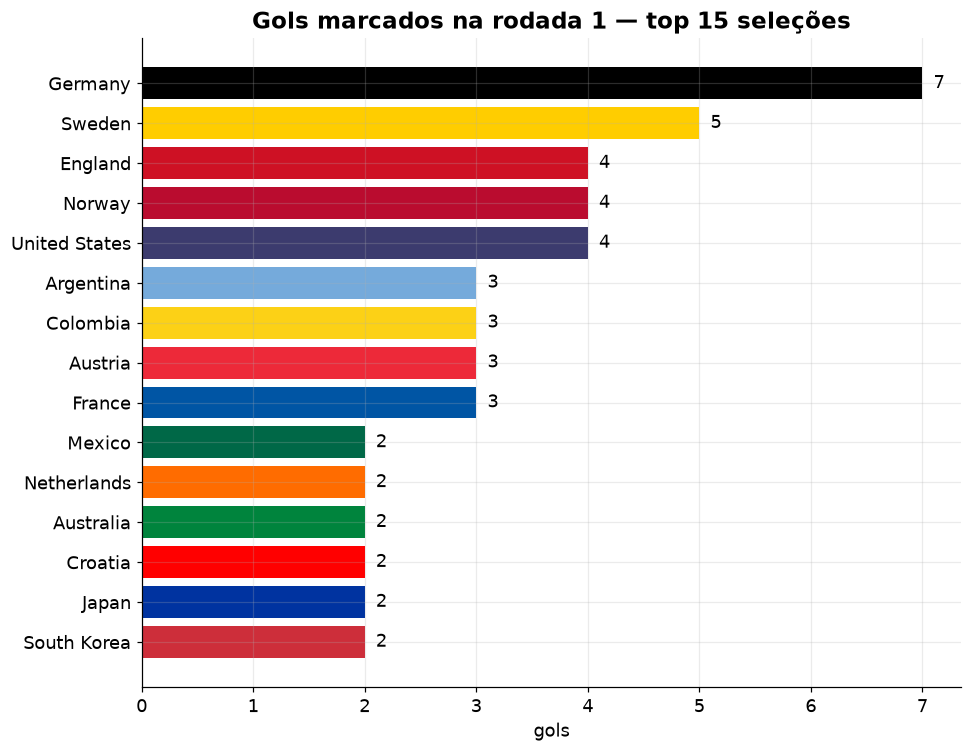

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15.index[::-1], top15.values[::-1], color=cores[::-1])
for i, v in enumerate(top15.values[::-1]):
    ax.text(v + 0.1, i, int(v), va="center")
ax.set_title("Gols marcados na rodada 1 — top 15 seleções")
ax.set_xlabel("gols")
plt.tight_layout()

🇩🇪 Alemanha lidera com sobra (os 7 gols da goleada sobre Curaçao). 🇸🇪 Suécia vem em segundo. Cinco seleções empatam com 4 gols: 🏴󠁧󠁢󠁥󠁮󠁧󠁿 Inglaterra, 🇳🇴 Noruega e 🇺🇸 Estados Unidos.

## Como ficou a classificação dos grupos depois da rodada 1?

Com isso dá pra ver quem já entra pressionado nas próximas duas rodadas.

In [19]:
def linha_time(row, lado):
    oposto = "away" if lado == "home" else "home"
    gf, ga = row[f"fulltime_{lado}"], row[f"fulltime_{oposto}"]
    pontos = 3 if gf > ga else (1 if gf == ga else 0)
    return row["group"], row[f"{lado}_team"], gf, ga, pontos

linhas = [linha_time(r, lado) for _, r in rodada1.iterrows() for lado in ("home", "away")]
classificacao = pd.DataFrame(linhas, columns=["group", "time", "gf", "ga", "pontos"])
classificacao.head()

,group,time,gf,ga,pontos
0,GROUP_A,Mexico,2.0,0.0,3
1,GROUP_A,South Africa,0.0,2.0,0
2,GROUP_A,South Korea,2.0,1.0,3
3,GROUP_A,Czechia,1.0,2.0,0
4,GROUP_B,Canada,1.0,1.0,1


In [20]:
classificacao["saldo"] = classificacao["gf"] - classificacao["ga"]
classificacao = classificacao.sort_values(["group", "pontos", "saldo"], ascending=[True, False, False])
classificacao["posicao"] = classificacao.groupby("group").cumcount() + 1
classificacao.head(8)

,group,time,gf,ga,pontos,saldo,posicao
0,GROUP_A,Mexico,2.0,0.0,3,2.0,1
2,GROUP_A,South Korea,2.0,1.0,3,1.0,2
3,GROUP_A,Czechia,1.0,2.0,0,-1.0,3
1,GROUP_A,South Africa,0.0,2.0,0,-2.0,4
4,GROUP_B,Canada,1.0,1.0,1,0.0,1
5,GROUP_B,Bosnia-Herzegovina,1.0,1.0,1,0.0,2
8,GROUP_B,Qatar,1.0,1.0,1,0.0,3
9,GROUP_B,Switzerland,1.0,1.0,1,0.0,4


In [21]:
lanternas = classificacao[classificacao["posicao"] == 4].sort_values("saldo")
lanternas[["group", "time", "pontos", "saldo"]]

,group,time,pontos,saldo
17,GROUP_E,Curaçao,0,-6.0
23,GROUP_F,Tunisia,0,-4.0
7,GROUP_D,Paraguay,0,-3.0
34,GROUP_I,Iraq,0,-3.0
37,GROUP_J,Algeria,0,-3.0
46,GROUP_K,Uzbekistan,0,-2.0
43,GROUP_L,Croatia,0,-2.0
1,GROUP_A,South Africa,0,-2.0
12,GROUP_C,Haiti,0,-1.0
29,GROUP_H,Uruguay,1,0.0


Vale o alerta: isso é baseado em **1 jogo só**, faltam 2 rodadas pela frente — não é eliminação, é só quem entra pressionado. 🇨🇼 Curaçao é o caso mais claro (saldo de `-6`, direto da goleada da Alemanha) porque esse tipo de diferença é difícil de reverter mesmo vencendo depois. Os outros lanternas têm 0 ponto mas saldo mais ameno, então uma vitória na rodada 2 já muda bastante o quadro.

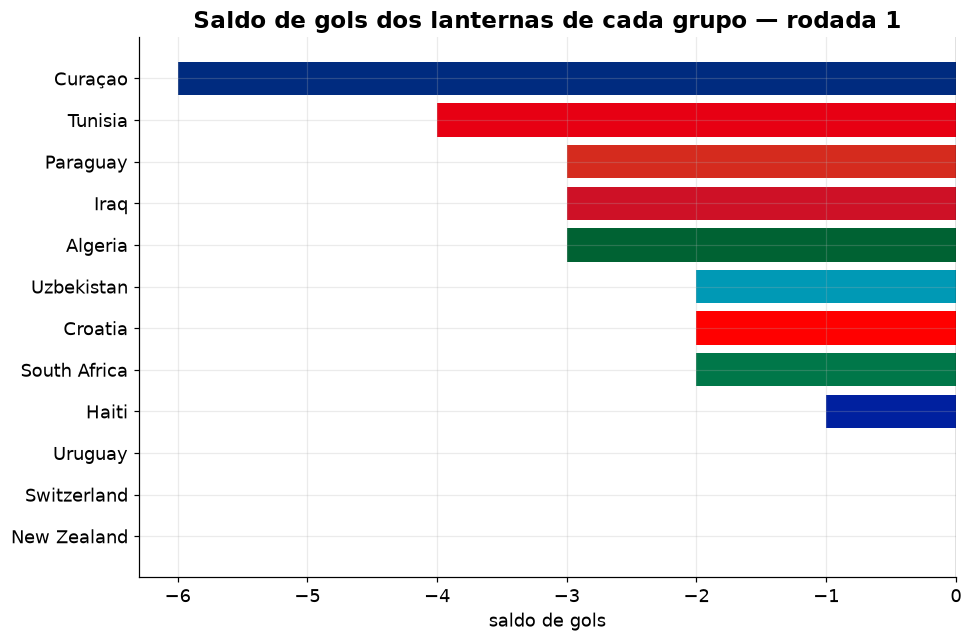

In [22]:
cores_risco = [bandeira_cor[t][1] for t in lanternas["time"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(lanternas["time"][::-1], lanternas["saldo"][::-1], color=cores_risco[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Saldo de gols dos lanternas de cada grupo — rodada 1")
ax.set_xlabel("saldo de gols")
plt.tight_layout()

🇨🇼 Curaçao se destaca isolado no risco — o saldo de `-6` é bem mais grave que o segundo pior caso (🇹🇳 Tunísia, `-4`). 🇺🇾 Uruguai, 🇨🇭 Suíça e 🇳🇿 Nova Zelândia empataram seus jogos, então aparecem com saldo `0` — ficaram em último por critério de desempate, não por terem ido mal.

## Teve jogo de virada na rodada 1?

Comparando o placar do intervalo com o placar final — quem estava perdendo e saiu com resultado melhor.

In [23]:
rodada1["diff_intervalo"] = rodada1["halftime_home"] - rodada1["halftime_away"]
rodada1["diff_final"] = rodada1["fulltime_home"] - rodada1["fulltime_away"]
rodada1[["home_team", "away_team", "diff_intervalo", "diff_final"]].head()

,home_team,away_team,diff_intervalo,diff_final
0,Mexico,South Africa,1.0,2.0
1,South Korea,Czechia,0.0,1.0
2,Canada,Bosnia-Herzegovina,-1.0,0.0
3,United States,Paraguay,3.0,3.0
4,Qatar,Switzerland,-1.0,0.0


In [24]:
viradas = rodada1[
    (rodada1["diff_intervalo"] < 0) & (rodada1["diff_final"] >= 0) |
    (rodada1["diff_intervalo"] > 0) & (rodada1["diff_final"] <= 0)
]
viradas[["home_team", "halftime_home", "halftime_away", "away_team", "fulltime_home", "fulltime_away"]]

,home_team,halftime_home,halftime_away,away_team,fulltime_home,fulltime_away
2,Canada,0.0,1.0,Bosnia-Herzegovina,1.0,1.0
4,Qatar,0.0,1.0,Switzerland,1.0,1.0
13,Belgium,0.0,1.0,Egypt,1.0,1.0
14,Saudi Arabia,1.0,0.0,Uruguay,1.0,1.0


4 jogos mudaram de lado depois do intervalo, mas em nenhum o time que tava perdendo virou pra vitória — todos pararam no empate (`1x1`). 🇧🇦 Bósnia, 🇨🇭 Suíça e 🇪🇬 Egito buscaram o empate depois de perder no intervalo; do outro lado, 🇺🇾 Uruguai escapou de uma derrota contra 🇸🇦 Arábia Saudita.

## E teve zebra?

Sem ranking nos dados, vou usar uma lista manual de seleções tradicionalmente favoritas (conhecimento de senso comum sobre futebol, não vem do dataset) e ver se algum "azarão" não perdeu pra um favorito.

In [25]:
favoritos = {"Brazil", "Argentina", "France", "England", "Spain", "Portugal", "Germany", "Netherlands", "Belgium"}

confrontos_desnivel = rodada1[
    rodada1["home_team"].isin(favoritos) ^ rodada1["away_team"].isin(favoritos)
]
confrontos_desnivel[["home_team", "fulltime_home", "fulltime_away", "away_team"]]

,home_team,fulltime_home,fulltime_away,away_team
5,Brazil,1.0,1.0,Morocco
8,Germany,7.0,1.0,Curaçao
9,Netherlands,2.0,2.0,Japan
12,Spain,0.0,0.0,Cape Verde Islands
13,Belgium,1.0,1.0,Egypt
16,France,3.0,1.0,Senegal
18,Argentina,3.0,0.0,Algeria
20,Portugal,1.0,1.0,Congo DR
21,England,4.0,2.0,Croatia


In [27]:
zebras = confrontos_desnivel[
    ((confrontos_desnivel["home_team"].isin(favoritos)) & (confrontos_desnivel["winner"] != "HOME_TEAM")) |
    ((confrontos_desnivel["away_team"].isin(favoritos)) & (confrontos_desnivel["winner"] != "AWAY_TEAM"))
]
zebras[["home_team", "fulltime_home", "fulltime_away", "away_team"]]

,home_team,fulltime_home,fulltime_away,away_team
5,Brazil,1.0,1.0,Morocco
9,Netherlands,2.0,2.0,Japan
12,Spain,0.0,0.0,Cape Verde Islands
13,Belgium,1.0,1.0,Egypt
20,Portugal,1.0,1.0,Congo DR


Nenhum favorito perdeu de fato na rodada 1, mas 5 deles tropeçaram no empate. O destaque é 🇪🇸 Espanha `0x0` 🇨🇻 Cabo Verde — ilha pequena, na primeira Copa da história, segurando o `0x0` contra uma das favoritas. 🇧🇷 Brasil também ficou no empate com 🇲🇦 Marrocos.

## Qual confederação da FIFA está indo melhor?

Vou mapear cada seleção pra sua confederação (UEFA, CONMEBOL, CONCACAF, CAF, AFC, OFC) e somar gols e pontos da rodada 1.

In [28]:
confederacao = {
    "Algeria": "CAF", "Argentina": "CONMEBOL", "Australia": "AFC", "Austria": "UEFA",
    "Belgium": "UEFA", "Bosnia-Herzegovina": "UEFA", "Brazil": "CONMEBOL", "Canada": "CONCACAF",
    "Cape Verde Islands": "CAF", "Colombia": "CONMEBOL", "Congo DR": "CAF", "Croatia": "UEFA",
    "Curaçao": "CONCACAF", "Czechia": "UEFA", "Ecuador": "CONMEBOL", "Egypt": "CAF",
    "England": "UEFA", "France": "UEFA", "Germany": "UEFA", "Ghana": "CAF",
    "Haiti": "CONCACAF", "Iran": "AFC", "Iraq": "AFC", "Ivory Coast": "CAF",
    "Japan": "AFC", "Jordan": "AFC", "Mexico": "CONCACAF", "Morocco": "CAF",
    "Netherlands": "UEFA", "New Zealand": "OFC", "Norway": "UEFA", "Panama": "CONCACAF",
    "Paraguay": "CONMEBOL", "Portugal": "UEFA", "Qatar": "AFC", "Saudi Arabia": "AFC",
    "Scotland": "UEFA", "Senegal": "CAF", "South Africa": "CAF", "South Korea": "AFC",
    "Spain": "UEFA", "Sweden": "UEFA", "Switzerland": "UEFA", "Tunisia": "CAF",
    "Turkey": "UEFA", "United States": "CONCACAF", "Uruguay": "CONMEBOL", "Uzbekistan": "AFC",
}
classificacao["confederacao"] = classificacao["time"].map(confederacao)
classificacao[["time", "confederacao"]].head()

,time,confederacao
0,Mexico,CONCACAF
2,South Korea,AFC
3,Czechia,UEFA
1,South Africa,CAF
4,Canada,CONCACAF


In [29]:
por_confederacao = classificacao.groupby("confederacao").agg(
    selecoes=("time", "count"), gols=("gf", "sum"), pontos=("pontos", "sum")
).sort_values("pontos", ascending=False)
por_confederacao

,selecoes,gols,pontos
confederacao,,,
UEFA,16,36.0,27
AFC,9,13.0,10
CAF,10,7.0,10
CONMEBOL,6,9.0,8
CONCACAF,6,8.0,7
OFC,1,2.0,1


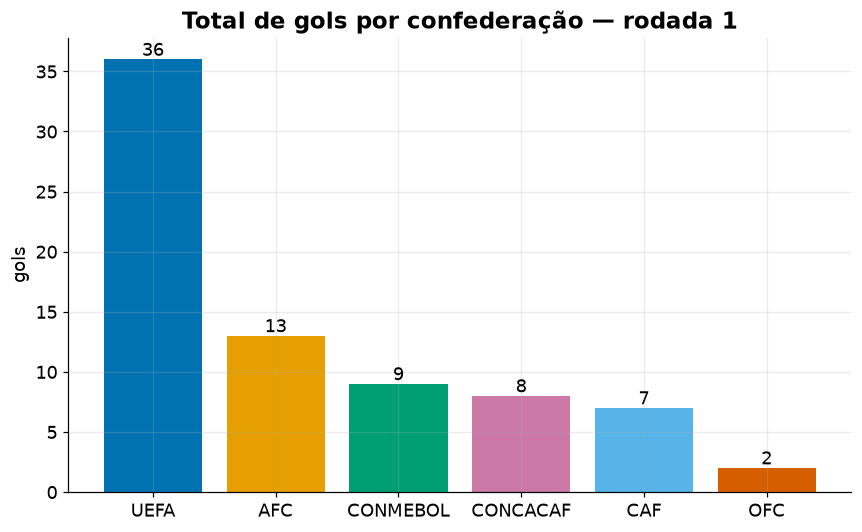

In [30]:
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
por_confederacao_gols = por_confederacao.sort_values("gols", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(por_confederacao_gols.index, por_confederacao_gols["gols"], color=PALETA)
for i, v in enumerate(por_confederacao_gols["gols"]):
    ax.text(i, v + 0.3, int(v), ha="center")
ax.set_title("Total de gols por confederação — rodada 1")
ax.set_ylabel("gols")
plt.tight_layout()

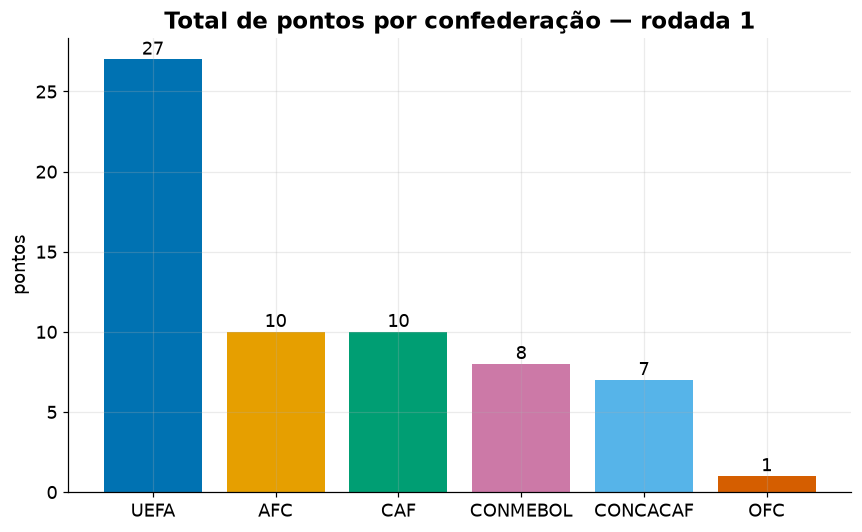

In [31]:
por_confederacao_pontos = por_confederacao.sort_values("pontos", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(por_confederacao_pontos.index, por_confederacao_pontos["pontos"], color=PALETA)
for i, v in enumerate(por_confederacao_pontos["pontos"]):
    ax.text(i, v + 0.3, int(v), ha="center")
ax.set_title("Total de pontos por confederação — rodada 1")
ax.set_ylabel("pontos")
plt.tight_layout()

UEFA lidera os dois rankings — mas ela também tem `16` seleções na Copa, muito mais que as outras (a OFC tem só `1`, a Nova Zelândia). Total maior é, em parte, só ter mais gente jogando. Pra saber quem realmente "está melhor" por seleção, vale olhar a média por time.

In [32]:
por_confederacao["gols_por_selecao"] = por_confederacao["gols"] / por_confederacao["selecoes"]
por_confederacao["pontos_por_selecao"] = por_confederacao["pontos"] / por_confederacao["selecoes"]
por_confederacao.sort_values("pontos_por_selecao", ascending=False)

,selecoes,gols,pontos,gols_por_selecao,pontos_por_selecao
confederacao,,,,,
UEFA,16,36.0,27,2.250000,1.687500
CONMEBOL,6,9.0,8,1.500000,1.333333
CONCACAF,6,8.0,7,1.333333,1.166667
AFC,9,13.0,10,1.444444,1.111111
CAF,10,7.0,10,0.700000,1.000000
OFC,1,2.0,1,2.000000,1.000000


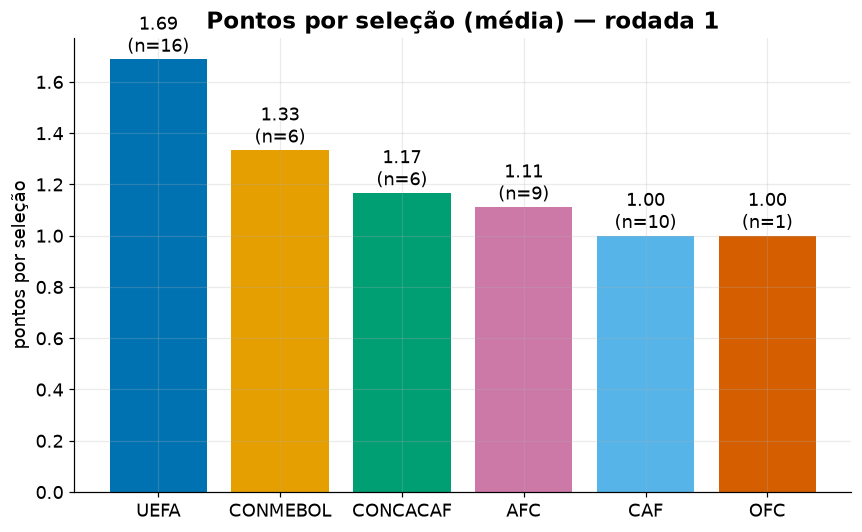

In [33]:
por_seleção = por_confederacao.sort_values("pontos_por_selecao", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(por_seleção.index, por_seleção["pontos_por_selecao"], color=PALETA)
for i, (v, n) in enumerate(zip(por_seleção["pontos_por_selecao"], por_seleção["selecoes"])):
    ax.text(i, v + 0.03, f"{v:.2f}\n(n={n})", ha="center")
ax.set_title("Pontos por seleção (média) — rodada 1")
ax.set_ylabel("pontos por seleção")
plt.tight_layout()

Mesmo olhando por seleção, a **UEFA** segue na frente (`1,69 pontos` por seleção, contra `1,0-1,33` das outras) — não é só efeito de ter mais times. CONMEBOL vem em segundo. A OFC empatar tecnicamente em 1º com a CAF não quer dizer nada: é a Nova Zelândia sozinha (`n=1`), um único empate.

Importante: isso é o retrato de **1 rodada apenas**. Pode mudar bastante depois das rodadas 2 e 3.

## Tem alguma seleção puxando a média da confederação pra cima?

Um swarmplot mostra cada seleção como um ponto — dá pra ver se a média alta da UEFA vem de um grupo consistente ou de uns poucos destaques isolados.

In [35]:
import seaborn as sns

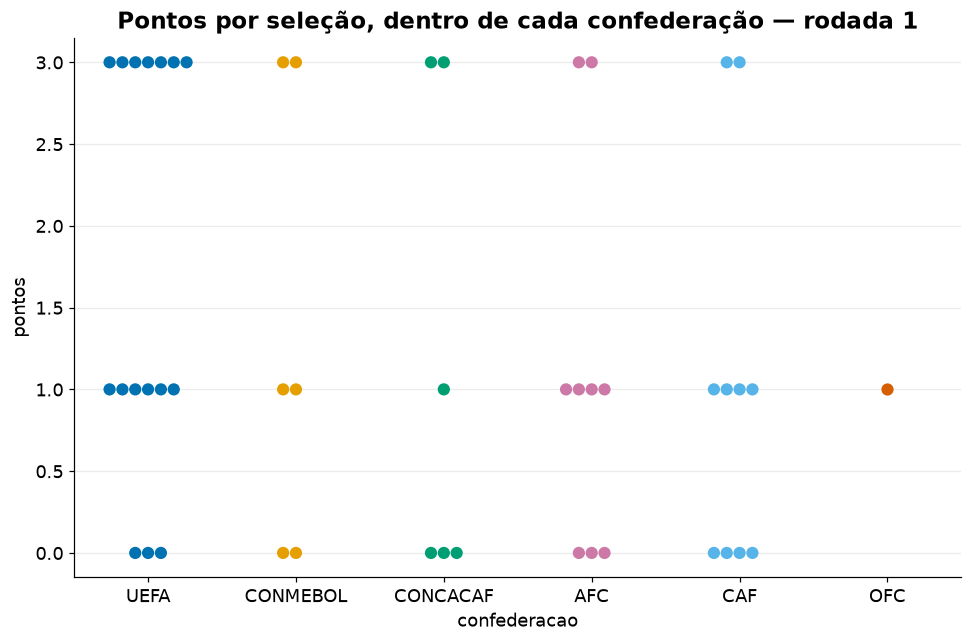

In [37]:
ordem = por_confederacao.sort_values("pontos_por_selecao", ascending=False).index.tolist()
cores_confed = dict(zip(ordem, PALETA))

fig, ax = plt.subplots(figsize=(9, 6))
sns.swarmplot(data=classificacao, x="confederacao", y="pontos", hue="confederacao", order=ordem, palette=cores_confed, size=8, legend=False, ax=ax)
ax.set_title("Pontos por seleção, dentro de cada confederação — rodada 1")
plt.tight_layout()

Em pontos não dá pra ter um "destaque isolado" — só existem `0`, `1` ou `3` por jogo. Pra ver outlier de verdade, gols é a métrica melhor (pode variar bem mais por jogo).

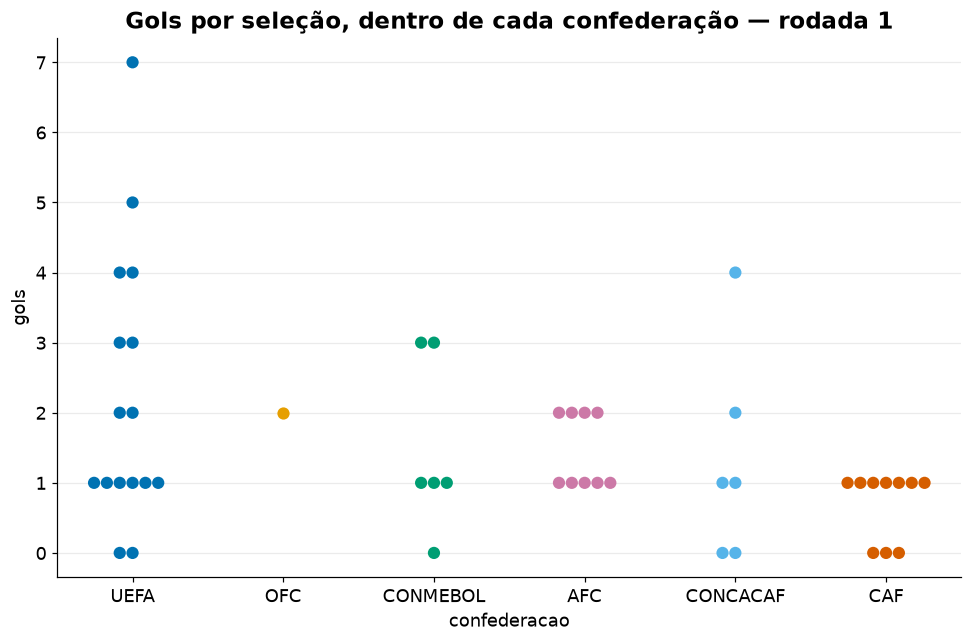

In [38]:
ordem_gols = por_confederacao.sort_values("gols_por_selecao", ascending=False).index.tolist()
cores_confed_gols = dict(zip(ordem_gols, PALETA))

fig, ax = plt.subplots(figsize=(9, 6))
sns.swarmplot(data=classificacao, x="confederacao", y="gf", hue="confederacao", order=ordem_gols, palette=cores_confed_gols, size=8, legend=False, ax=ax)
ax.set_title("Gols por seleção, dentro de cada confederação — rodada 1")
ax.set_ylabel("gols")
plt.tight_layout()

In [39]:
media_com = classificacao.groupby("confederacao")["gf"].mean()
sem_o_artilheiro = classificacao.loc[classificacao.groupby("confederacao")["gf"].idxmax()]
media_sem = classificacao.drop(sem_o_artilheiro.index).groupby("confederacao")["gf"].mean()
pd.DataFrame({"media_com_outlier": media_com, "media_sem_outlier": media_sem, "quem_e_o_outlier": sem_o_artilheiro.set_index("confederacao")["time"]})

,media_com_outlier,media_sem_outlier,quem_e_o_outlier
confederacao,,,
AFC,1.444444,1.375000,South Korea
CAF,0.700000,0.666667,Morocco
CONCACAF,1.333333,0.800000,United States
CONMEBOL,1.500000,1.200000,Argentina
OFC,2.000000,NaN,New Zealand
UEFA,2.250000,1.933333,Germany


Aqui está a resposta: tirando o artilheiro de cada confederação,

- **UEFA** quase não muda (`2,25 → 1,93` gols/seleção) — a 🇩🇪 Alemanha (7 gols) ajuda, mas a confederação seguiria na frente de qualquer forma, com vários times de 2 a 4 gols.
- **CONCACAF** despenca (`1,33 → 0,80`) — sem os 4 gols dos 🇺🇸 Estados Unidos, a confederação cai pra perto da CAF, a pior do grupo.
- **CONMEBOL** também sente um pouco (`1,50 → 1,20`) com a 🇦🇷 Argentina.

Ou seja: a liderança da UEFA é "de verdade" (vários times bem, não um só herói); o destaque do CONCACAF, por outro lado, é quase todo Estados Unidos.